In [25]:
import os

base = r"dataset"

# Supported image extensions
IMG_EXTS = (".jpg", ".jpeg", ".png", ".tiff", ".webp", ".avif")

def get_images(path):
    return [f for f in os.listdir(path) if f.lower().endswith(IMG_EXTS)]

def get_labels(path):
    return [f for f in os.listdir(path) if f.endswith(".txt")]

# TRAIN
train_images = get_images(os.path.join(base, "images/train"))
train_labels = get_labels(os.path.join(base, "labels/train"))

# VAL
val_images = get_images(os.path.join(base, "images/val"))
val_labels = get_labels(os.path.join(base, "labels/val"))

print("---- COUNTS ----")
print("Train images:", len(train_images))
print("Train labels:", len(train_labels))
print("Val images:", len(val_images))
print("Val labels:", len(val_labels))

# Name matching check
train_img_names = {os.path.splitext(f)[0] for f in train_images}
train_lbl_names = {os.path.splitext(f)[0] for f in train_labels}

val_img_names = {os.path.splitext(f)[0] for f in val_images}
val_lbl_names = {os.path.splitext(f)[0] for f in val_labels}

print("\n---- TRAIN MISMATCH ----")
print("Images without labels:", train_img_names - train_lbl_names)
print("Labels without images:", train_lbl_names - train_img_names)

print("\n---- VAL MISMATCH ----")
print("Images without labels:", val_img_names - val_lbl_names)
print("Labels without images:", val_lbl_names - val_img_names)

---- COUNTS ----
Train images: 42
Train labels: 42
Val images: 10
Val labels: 10

---- TRAIN MISMATCH ----
Images without labels: {'elephants-river-eating-reeds-260nw-2676662857', 'f', 'fe', 'tg', 'fefe', 'ef', 'elephants-river-eating-reeds-260nw-2676662839', 'gtt'}
Labels without images: {'gtt.xml', 'elephants-river-eating-reeds-260nw-2676662857.xml', 'elephants-river-eating-reeds-260nw-2676662839.xml', 'w.xml', 'fe.xml', 'ef.xml', 'tg.xml', 'fefe.xml'}

---- VAL MISMATCH ----
Images without labels: {'gt', 'big-tusk-elephant-standing-river-260nw-1741688756'}
Labels without images: {'big-tusk-elephant-standing-river-260nw-1741688756.xml', 'gt.xml'}


In [1]:
import os

folders = [
r"dataset/labels\train",
r"dataset/labels\val"
]

for folder in folders:
    for file in os.listdir(folder):

        if file.endswith(".txt"):
            path = os.path.join(folder, file)

            new_lines = []

            with open(path, "r") as f:
                lines = f.readlines()

            for line in lines:

                parts = line.strip().split()

                if len(parts) == 0:
                    continue

                cls = int(parts[0])

                # REMOVE old class 0
                if cls == 0:
                    continue

                # SHIFT classes down
                new_class = cls - 1

                parts[0] = str(new_class)

                new_lines.append(" ".join(parts) + "\n")

            with open(path, "w") as f:
                f.writelines(new_lines)

print("All label files fixed successfully.")

All label files fixed successfully.


In [11]:
import os
from collections import Counter

folder = r"dataset/images\train"

class_counts = Counter()
total_files = 0
total_objects = 0

for root, dirs, files in os.walk(folder):
    for file in files:

        # read any label-like file
        if file.endswith(".txt"):
            path = os.path.join(root, file)
            total_files += 1

            with open(path, "r") as f:
                for line in f:
                    parts = line.strip().split()

                    if len(parts) >= 5:
                        try:
                            cls = int(parts[0])
                            class_counts[cls] += 1
                            total_objects += 1
                        except:
                            pass

print("\n===== DATASET SUMMARY =====")
print("Label files found:", total_files)
print("Total objects:", total_objects)

print("\n===== CLASS COUNTS =====")
for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")


===== DATASET SUMMARY =====
Label files found: 142
Total objects: 206

===== CLASS COUNTS =====
Class 0: 25
Class 1: 109
Class 2: 46
Class 3: 26


In [12]:
import os
import re

folder = r"dataset/images\train"

for file in os.listdir(folder):

    if file.endswith(".txt"):

        old_path = os.path.join(folder, file)

        # remove things like .jpg, .png, .xml before .txt
        new_name = re.sub(r'\.(jpg|jpeg|png|xml)\.txt$', '.txt', file)

        new_path = os.path.join(folder, new_name)

        if old_path != new_path:
            os.rename(old_path, new_path)
            print(f"Renamed: {file} → {new_name}")

print("\nDone cleaning label filenames.")

Renamed: 00046_result_3_png_jpg.rf.3daffaadfd68a96f14cb0611432b5def.xml.txt → 00046_result_3_png_jpg.rf.3daffaadfd68a96f14cb0611432b5def.txt
Renamed: 00055_result_2_png_jpg.rf.19480dde28ad0d546d9815e15fd7c641.xml.txt → 00055_result_2_png_jpg.rf.19480dde28ad0d546d9815e15fd7c641.txt
Renamed: 00083_result_1_png_jpg.rf.c0fbcfe2a79534ce1055540716ab7cce.xml.txt → 00083_result_1_png_jpg.rf.c0fbcfe2a79534ce1055540716ab7cce.txt
Renamed: 00083_result_2_png_jpg.rf.a277ad6d37f93f9eb333e39c1719069a.xml.txt → 00083_result_2_png_jpg.rf.a277ad6d37f93f9eb333e39c1719069a.txt
Renamed: 00110_result_2_png_jpg.rf.888084a3e2b79f0219930485f0f582de.xml.txt → 00110_result_2_png_jpg.rf.888084a3e2b79f0219930485f0f582de.txt
Renamed: 00110_result_7_png_jpg.rf.3b16621d800396a098c745feea8ce748.xml.txt → 00110_result_7_png_jpg.rf.3b16621d800396a098c745feea8ce748.txt
Renamed: 00112_result_1_png_jpg.rf.a94d47209aae70234990ff5c87b05caf.xml.txt → 00112_result_1_png_jpg.rf.a94d47209aae70234990ff5c87b05caf.txt
Renamed: 0012

In [13]:
import os
import random
import shutil

base_folder = r"dataset/images\train"

train_img = r"dataset/images\train"
val_img = r"dataset/images\val"

train_lbl = r"dataset/labels\train"
val_lbl = r"dataset/labels\val"

os.makedirs(val_img, exist_ok=True)
os.makedirs(train_lbl, exist_ok=True)
os.makedirs(val_lbl, exist_ok=True)

images = [f for f in os.listdir(base_folder) if f.endswith((".jpg",".png",".jpeg",".webp",".avif"))]

random.shuffle(images)

split_index = int(0.8 * len(images))

train_files = images[:split_index]
val_files = images[split_index:]

for img in train_files:

    label = os.path.splitext(img)[0] + ".txt"

    shutil.move(os.path.join(base_folder,img), os.path.join(train_img,img))

    if os.path.exists(os.path.join(base_folder,label)):
        shutil.move(os.path.join(base_folder,label), os.path.join(train_lbl,label))

for img in val_files:

    label = os.path.splitext(img)[0] + ".txt"

    shutil.move(os.path.join(base_folder,img), os.path.join(val_img,img))

    if os.path.exists(os.path.join(base_folder,label)):
        shutil.move(os.path.join(base_folder,label), os.path.join(val_lbl,label))

print("Dataset split complete.")

Dataset split complete.


In [14]:
import os
import cv2
import random
import shutil

img_folder = r"dataset/images\train"
lbl_folder = r"dataset/labels\train"

for label_file in os.listdir(lbl_folder):

    path = os.path.join(lbl_folder,label_file)

    with open(path) as f:
        lines = f.readlines()

    classes = [int(l.split()[0]) for l in lines]

    if 0 in classes or 3 in classes:

        img_name = label_file.replace(".txt",".jpg")
        img_path = os.path.join(img_folder,img_name)

        if os.path.exists(img_path):

            img = cv2.imread(img_path)

            for i in range(2):

                aug = img.copy()

                if random.random() > 0.5:
                    aug = cv2.flip(aug,1)

                if random.random() > 0.5:
                    aug = cv2.GaussianBlur(aug,(5,5),0)

                alpha = 1 + random.uniform(-0.2,0.2)
                beta = random.randint(-20,20)

                aug = cv2.convertScaleAbs(aug,alpha=alpha,beta=beta)

                new_img = img_name.replace(".jpg",f"_aug{i}.jpg")
                new_lbl = label_file.replace(".txt",f"_aug{i}.txt")

                cv2.imwrite(os.path.join(img_folder,new_img),aug)

                shutil.copy(path, os.path.join(lbl_folder,new_lbl))

print("Augmentation complete.")

Augmentation complete.


In [ ]:
from ultralytics import YOLO
import cv2

model = YOLO("runs/detect/train13/weights/best.pt")

results = model.predict(
    source="dataset/images/val",
    conf=0.25
)

for r in results:
    img = r.plot()   # image with boxes
    cv2.imshow("Detection", img)
    cv2.waitKey(0)

cv2.destroyAllWindows()


image 1/29 dataset/images\val\00083_result_1_png_jpg.rf.c0fbcfe2a79534ce1055540716ab7cce.jpg: 960x960 1 elephant, 1191.7ms
image 2/29 dataset/images\val\00083_result_2_png_jpg.rf.a277ad6d37f93f9eb333e39c1719069a.jpg: 960x960 1 elephant, 812.9ms
image 3/29 dataset/images\val\1970-01-01_00-14-09-396778_png_jpg.rf.5b4a49cc4acb765a8b8602a4fed88aec.jpg: 960x960 1 elephant, 1209.8ms
image 4/29 dataset/images\val\1970-01-02_03-40-18-032745_png_jpg.rf.d1894f92d928823f7c8b59e0ae352b85.jpg: 960x960 1 elephant, 1261.2ms
image 5/29 dataset/images\val\Elephant-Stephanie-Foote-1.avif: 480x960 1 elephant, 1049.5ms
image 6/29 dataset/images\val\FROS5660-925x600.jpg: 640x960 1 elephant, 1157.2ms
image 7/29 dataset/images\val\SEI_150766882.webp: 544x960 1 elephant, 1025.5ms
image 8/29 dataset/images\val\The-anatomy-of-an-african-elephant-scaled.jpg: 640x960 1 elephant, 841.4ms
image 9/29 dataset/images\val\as_tr136.jpg: 640x960 1 elephant, 1000.9ms
image 10/29 dataset/images\val\as_tr178.jpg: 544x960 2

In [12]:
import os

label_dir = r"dataset/labels\train"

counts = {}

for file in os.listdir(label_dir):
    if file.endswith(".txt"):
        with open(os.path.join(label_dir, file)) as f:
            for line in f:
                cls = line.split()[0]
                counts[cls] = counts.get(cls, 0) + 1

print(counts)

{'1': 90, '0': 71, '2': 128, '3': 72}


In [1]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

Torch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
Device count: 1


In [3]:
import os
import cv2

folder = r"dataset/images\train"

for f in os.listdir(folder):
    path = os.path.join(folder, f)
    img = cv2.imread(path)

    if img is None:
        print("Corrupt:", f)
        continue

    h, w = img.shape[:2]

    if h > 3000 or w > 3000:
        print("Large image:", f, h, w)

Large image: 178_Male_African_bush_elephant_in_Etosha_National_Park_Photo_by_Giles_Laurent.jpg 5475 8213
Large image: army-weapon-bullets-projectile-8cabe83b3f738310d17709936aa1944b.jpg 3744 5616
Large image: poacher5 (1).webp 2160 3840


In [1]:
from ultralytics import YOLO
import torch

# Confirm GPU
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

# Load pretrained YOLO model
model = YOLO("yolov8s.pt")

# Train model
results = model.train(

    data="data.yaml",

    # Training settings
    epochs=60,
    imgsz=832,
    batch=12,           # safer for 8GB GPU
    device=0,           # use GPU
    workers=2,          # prevents Windows RAM crash

    optimizer="AdamW",
    lr0=0.0008,
    cos_lr=True,

    # Freeze backbone layers (important for small datasets)
    freeze=10,

    patience=20,

    # Augmentations
    mosaic=1.0,
    mixup=0.2,
    scale=0.9,
    translate=0.2,
    degrees=10,
    shear=2,

    fliplr=0.5,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    cache=False,

    verbose=True
)

print("Training complete.")

Torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.16  Python-3.9.25 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=832, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0008, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=trai


image 1/10 dataset/images\test\876543x-scaled.jpg: 512x832 1 gun, 2 humans, 58.7ms


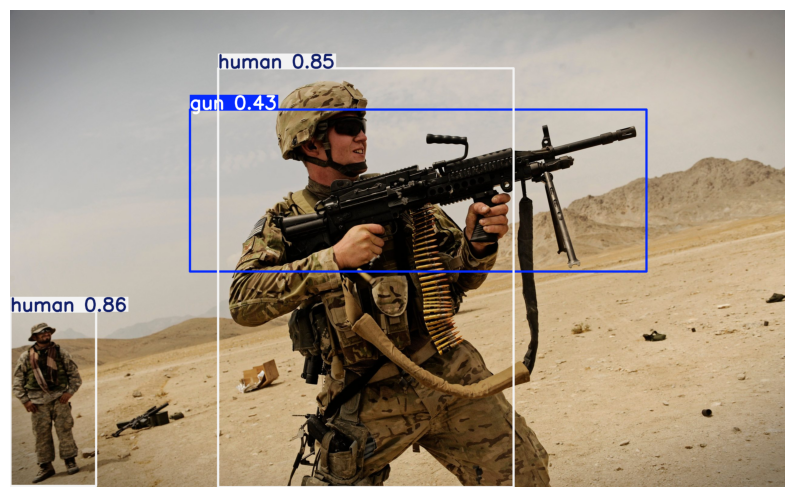

image 2/10 dataset/images\test\ELEPHANT (10).jpg: 512x832 3 elephants, 57.1ms


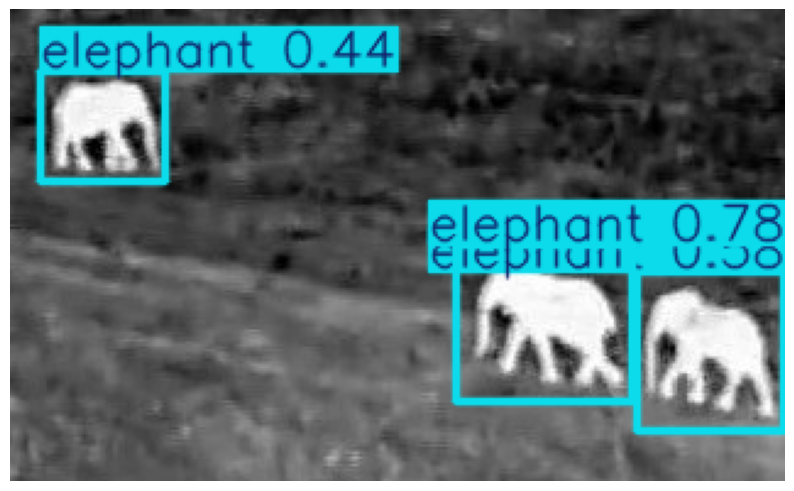

image 3/10 dataset/images\test\ELEPHANT (8).png: 832x576 1 elephant, 65.2ms


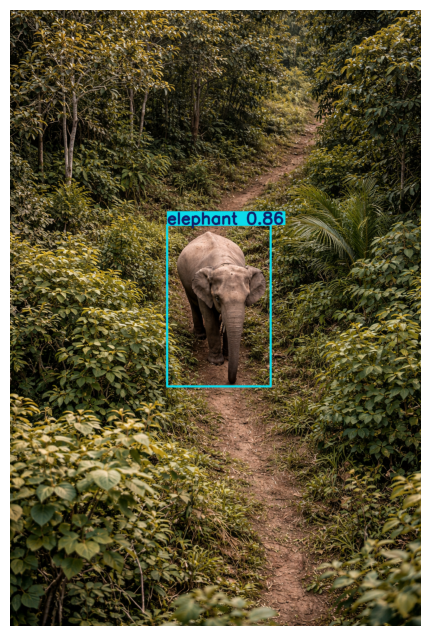

image 4/10 dataset/images\test\FOREST_RANGER (2).png: 576x832 1 human, 1 jacket, 65.4ms


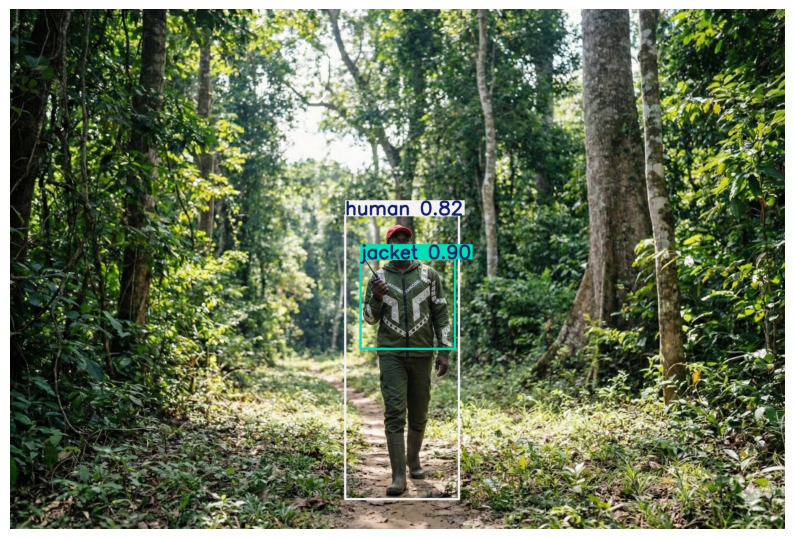

image 5/10 dataset/images\test\FOREST_RANGER (20).png: 576x832 1 human, 1 jacket, 61.8ms


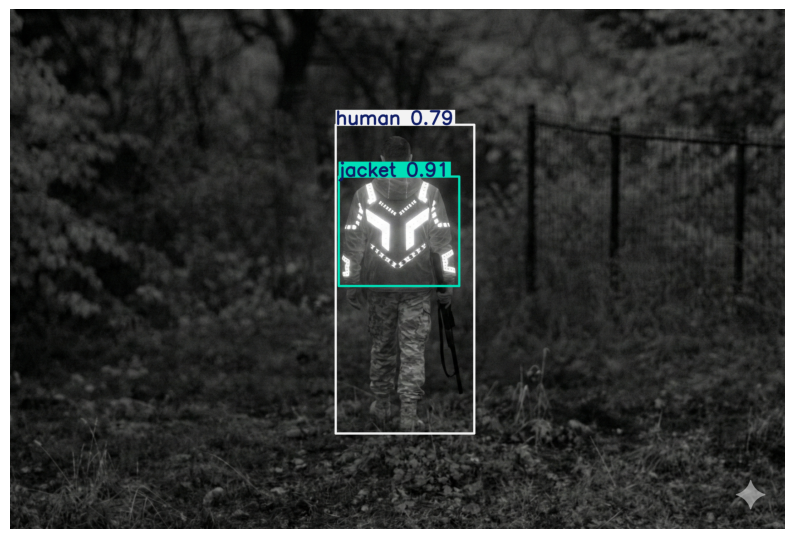

image 6/10 dataset/images\test\POACHER (6).png: 480x832 2 humans, 71.6ms


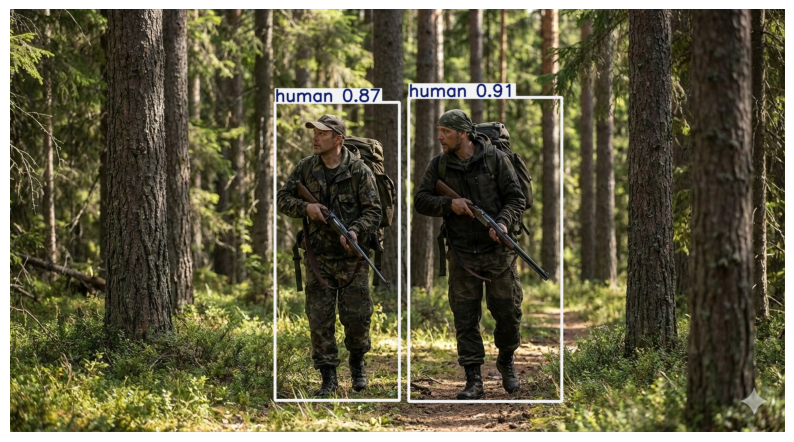

image 7/10 dataset/images\test\army-weapon-bullets-projectile-8cabe83b3f738310d17709936aa1944b.jpg: 576x832 1 gun, 1 human, 65.8ms


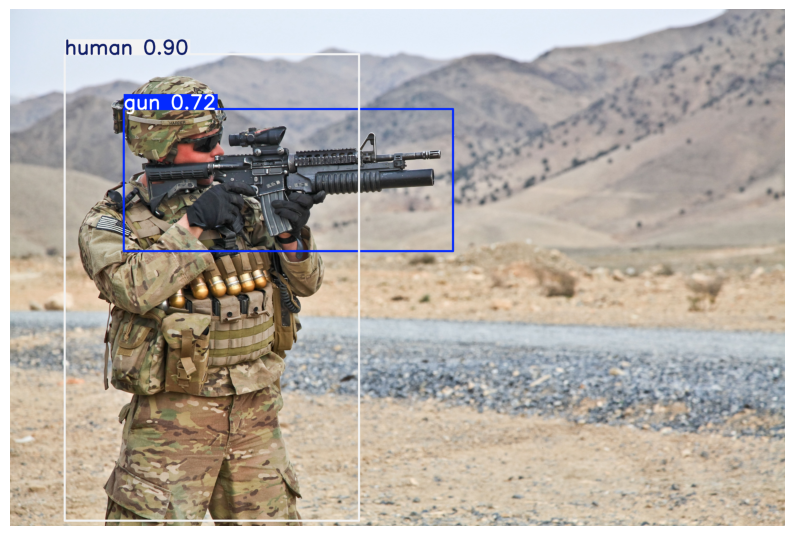

image 8/10 dataset/images\test\images.jpg: 768x832 1 gun, 1 human, 85.4ms


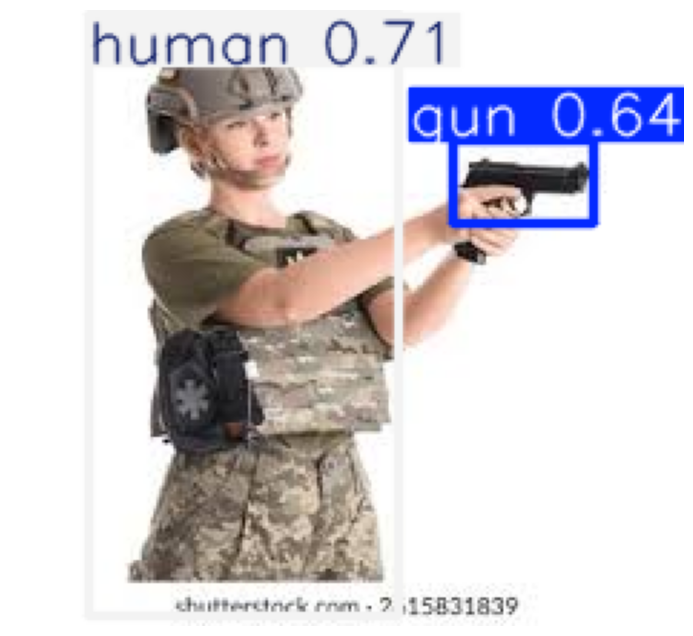

image 9/10 dataset/images\test\person-looks-up-while-standing-in-a-forest.jpg: 576x832 1 human, 61.1ms


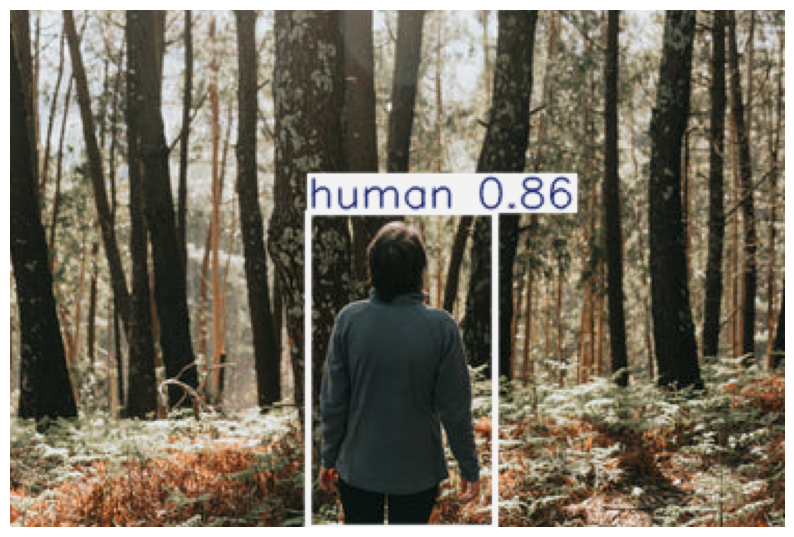

image 10/10 dataset/images\test\poacher_POACHER_IR_7.jpg: 576x832 2 humans, 57.6ms


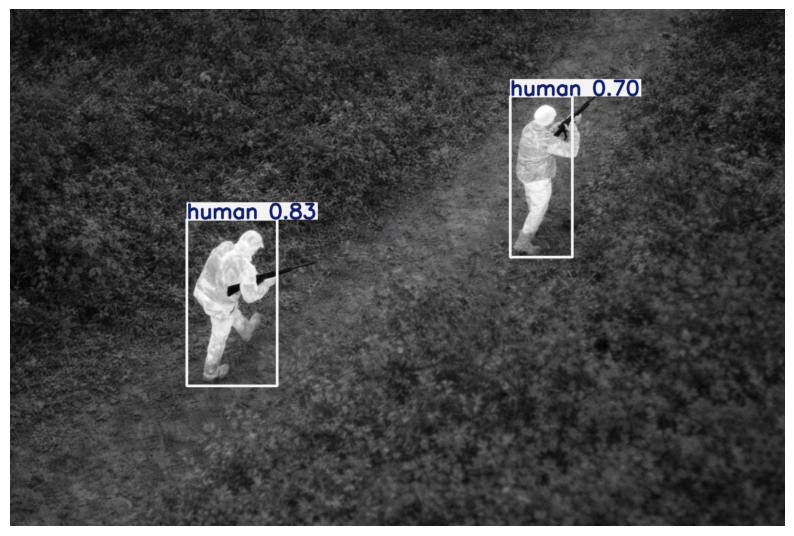

Speed: 12.5ms preprocess, 65.0ms inference, 5.3ms postprocess per image at shape (1, 3, 576, 832)


In [5]:
%matplotlib inline

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model = YOLO("runs/detect/train17/weights/best.pt")

results = model.predict(
    source=r"dataset/images\test",
    conf=0.40,
    stream=True
)

for r in results:

    img = r.plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()